# ISS_decoding of preprocessed files

This notebook guides you through the steps necessary for the decoding of ISS image data that have been preprocessed using our `ISS_preprocessing` module.

In this step, we make use of the starfish library to extract the information contained in our images. starfish is a Python library for processing images of image-based spatial transcriptomics. You can read more about it here: https://spacetx-starfish.readthedocs.io/en/latest/

In the following steps, we first format our images to a starfish-compatible format (SpaceTx), and provide some information about our experiment design. 
Once this is completed, we can proceed to the actual decoding of the data from the SpaceTx images.

For this notebook to work correctly, you should have a specific folder for each one of the regions you want to process, `/R1/`, `/R2/`, etc. Each region folder should contain the following subfolders tree: `/preprocessing/CycleX/4_retiled`. Under `/preprocessing/` you might still have other subfolders such as `/1_mipped/`, `/2_ome_tiffs/` and `/3_stitched/`, but these are irrelevant at this stage.

The important thing is that you have a `/preprocessing/CycleX/4_retiled/`, because the retiled images are the starting point of the decoding process.

## We start by importing the necessary modules

In [1]:
import ISS_decoding.SpaceTx_format as STX
import ISS_decoding.decoding as DEC
import ISS_decoding.qc_metrics as QC
import pandas as pd
from pathlib import Path

/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_decoding/lib/python3.11/site-packages/starfish/core/util/logging.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Format the images to SpaceTx format

The first thing to do before we can start the actual decoding is to transform our images (the resliced tiles) to the SpaceTx format.

To read more about the SpaceTx format, read the following: https://github.com/spacetx/sptx-format

Let's look at the variables are taken by the function:

`input_dir` = type: `str`. Path to the parent directory containing the preprocessed region folders (e.g., `/R1/`, `/R2/`, …).  
These region folders are automatically generated by the preprocessing module.  
The `input_dir` is referenced throughout this notebook.

`codebook_csv` = type: `str`. This is a file that associates a unique color sequence across ISS cycles to each gene. This file is a comma separated file with no header, in which the first column contains the gene name, while  columns 2 to 6 (in case of a 6 cycle experiment) contain numbers representing the expected positive DO_decorator in each cycle for that gene. 

`pixelscale`  = type: `int`. This is the size of the pixels in microns. This is needed if you want the coordinates of the spot to be output in microns, and will depend on your microscope settings. Set to 1 if you want the data to be on a coordinate scale. Default = 0.1625.

`channels` = type: `list`. The channels, in the order they were acquired in the microscope. Default = ["AF750", "Cy5", "Cy3", "AF488", "DAPI"]

`DO_decorators` =  type: `list` **This point can be tricky to understand.** This shows how you associate the numbers in the codebook (ie 1,2,3,4) to a specific list of colors (DO_decorator) . In our lab, 1,2,3,4,5 correspond to  ["AF750", "488", "Cy3",  "Cy5", "at425"]. 

Default =  ["AF750", "488", "Cy3",  "Cy5"]. Users who will follow our barcode design and readout schemes should not change this.

`nuclei_channel`  = type: `str`. This is the name of the channel that corresponds to your nuclei stained image. Default =  "DAPI".








In [ ]:
input_dir = '/path/to/regions/'
codebook_csv = '/path/to/codebook/'

In [6]:
input_dir = '/mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/'
codebook_csv = '/mnt/DATA/ext_home/saga/test/saga/codebook_organoid_mock.csv'

In [ ]:
STX.make_spacetx_format(
    input_dir,
    codebook_csv,
    pixelscale=1,
    channels=["AF750", "Cy5", "Cy3", "AF488", "DAPI", "At425"],
    DO_decorators=["AF750", "AF488", "Cy3", "Cy5", "At425"],
    nuclei_channel="DAPI",
    )


## Decode the SpaceTx formatted data


At this stage, after running the above code block, you should have successfully transformed your preprocessed tiles into the SpaceTx format. Each `/decoding/SpaceTX_format/` should now contain a file called `experiment.json`

To decode the images, we now need to use the `process_experiment` function.


In brief, the function will take each individual SpaceTx image file, looks for the same spot across cycles, deduce a colour sequence for each spot across the different cycles, and match the extracted sequence to the `codebook` we provided previously. 

In detail, this process is actually a bit more complex and several steps happen within the `process_experiment` function. We suggest you to have a look at the relevant part of the manual for exhaustive explanation of what happens under the hood. 

### Changing decoding parameters

Modifying some of  the input parameters of the `process_experiment` function, it is possible to explore a range of settings to optimize the decoding for every specific experiment, if necessary.

`input_dir` = type: `str`. Path to the directory storing you preprocessed region folders, that is, the path to the parent directory to the automatically produced folders from the preprocessing module saved as `/R1/`, `/R2/`, etc. This is the same directory as used above.

`register`: select `True` if you want to register/align your images and `False` if you don’t want to align your images. In principle, this should be already taken care of by the `ISS_preprocessing` module. Nevertheles, this step is also recommended, as sometimes small adjustments in the registration of images improve this step.

`register_dapi`: specify `True` if you want to align your images based on Dapi/ nuclear staining. If it’s specified as `False`, the alignment will be done based on a pseudoanchor(please read the glossary on the manual to know what this is). This parameter only is considered if the parameter `Register==True`.

`masking radius`: the radius of the top hat filter for spot detection. Depending on the size, it will “smoothen” your data to a different extent. The standard values go between 7 and 15. We recommend 7. Refer to the manual for further explanations.

`normalization method`: ‘MH’ or ‘CPTZ’. These are two alternative image normalization methods. We normally advise to use 'MH' for ISS data. Please refer to the manual to understand the differences.

`decode_mode`: two options are given: ‘PRMC’: per round max channel OR ‘MD’, metric distance. We suggest to use PRMC. More information on how the two methods differ are in the manual.

`dense`: This parameter, when set to =True enables decoding in **dense mode**. This is particularly suitable for very dense data. If dense =False (default) the software first identifies all the spots in a *pseudoanchor*, an artificial image that is built by overlapping all the channels. While this modality is suitable and faster for relatively sparse data, it leads to a serious underestimation of the number of spots in dense images. If dense is set to =True, the spot calling is performed on individual channels. This slows down the decoding by a factor of 5x, so think about it before you use it on large sections.

`spot_detection_mode`: 'starfish' or 'spotiflow'.

`int_threshold`: Defines the minimum intensity that a spot should have in order to be detected. Decreasing the threshold increases the number of detected spots, but also increases the chance of background signal being counted as a spot. Required for `spot_detection_mode`='starfish'.

`sigma vals`:  correspond to min_sigma, max_sigma, num_sigma. See https://spacetx-starfish.readthedocs.io/en/latest/api/spots/index.html#spot-finding. Our default values are set in a way that allow us to capture signals in our experimental settings, on both Leica and Zeiss and at both 20x and 40x magnifications. Required for `spot_detection_mode`='starfish'.

`prob_threshold`: Defines the minimum a detection probability/confidence (0 to 1) for the spotiflow prediction output. This can be kept low and filtered out in later steps.  If None, will load the optimal one. Defaults to None. Required for `spot_detection_mode`='spotiflow'.

However the above parameters are specified, the output decoded files will always be .csv files consisting essentially of the location (XY position) and identity (gene) of every spot decoded. 


In [8]:
DEC.process_experiment(
    input_dir, 
    register = False,
    register_dapi = False,
    masking_radius = 7,
    normalization_method = 'MH',
    decode_mode = 'PRMC',
    dense=True,
    spot_detection_mode='starfish',
    int_threshold = 0.002, 
    sigma_vals = [1, 10, 30] # min, max and number
            )




Processing directory: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish
DENSE (per-channel) decoding
Processing region R1
Output decoded directory: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/decoding/2_decoded_dense
Found 0 output files
-> 4 tiles left to process
Processing tile 000 
Loading image planes


 12%|███████                                                    | 3/25 [00:04<00:32,  1.46s/it]

Locating spots for channel 0
Locating spots for channel 1
Locating spots for channel 2
Locating spots for channel 3
Locating spots for channel 4
Saving per-tile CSV: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/decoding/2_decoded_dense/fov_000.csv
Processing tile 001 
Loading image planes


100%|██████████████████████████████████████████████████████████| 25/25 [00:01<00:00, 15.50it/s]


Not registering images, applying filter to raw data


...

Normalizing channel intensities
Locating spots for channel 0
Locating spots for channel 1
Locating spots for channel 2
Locating spots for channel 3
Locating spots for channel 4
Saving per-tile CSV: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/decoding/2_decoded_dense/fov_002.csv
Processing tile 003 
Loading image planes


100%|██████████████████████████████████████████████████████████| 25/25 [00:06<00:00,  4.00it/s]


Not registering images, applying filter to raw data


100%|█████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 586.37it/s]


Normalizing channel intensities
Locating spots for channel 0
Locating spots for channel 1
Locating spots for channel 2
Locating spots for channel 3
Locating spots for channel 4
Saving per-tile CSV: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/decoding/2_decoded_dense/fov_003.csv

Writing region-level concatenated CSV for 'R1' ...
  • Loaded fov_000.csv (7047 rows)
  • Loaded fov_001.csv (24631 rows)
  • Loaded fov_002.csv (5760 rows)
  • Loaded fov_003.csv (12010 rows)
 → Wrote 49448 total rows to R1_decoded.csv


# Explore the decoded data

Now we should have as an output a big table (saved in csv) containing the information of our raw decoded spots. The main columns are: 

1. The location of the decoded spot (columns “xc” and “yc”) and 

2. the identity of every spot (column: “target”). 

Similarly to what happens in NGS experiments, there "raw" reads migh have variable quality and one key step before performing downstream analyses is to assess this quality and filter the data if necessary (**spoiler alert: it is always necessary to do some level of filtering**)

#### Processing Reads for Individual Regions

We will now process each region individually (`R1`, `R2`, etc.).
For each region, we must assess the quality of its reads separately to ensure accurate results for that specific region.

**Step 1:** Read the combined CSV file for a single region.

- **Inputs:**
  - `region` (string): Name of the region, e.g., `'R1'`, `'R2'`.
  - `dense` (boolean):  
    - `True` → read from `2_decoded_dense/{region}_decoded.csv`  
    - `False` → read from `2_decoded/{region}_decoded.csv`
- **Path construction:**  
  The file path should be built automatically from `input_dir`, `region`, and `dense`.



In [7]:
region = 'R1'
dense = True

reads = pd.read_csv(
    Path(input_dir)
    / region
    / 'decoding'
    / f"2_decoded{'_dense' if dense else ''}"
    / f"{region}_decoded.csv"
)


The number of extracted raw reads for this section is:

In [8]:
len(reads)

49448

## Understanding read quality

To have an idea of how the read quality looks like, we can generate a violin plot of the qualities per cycle using the `quality_per_cycle` function. The function gets the data from the `reads` table above. The number of cycles is infered from the `reads` table. 

You can have a look at the manual to understand how the quality is calculated. Summing up, 1 is the theoretical maximum and 0.25 the theoretical minimum in a 4 colour setting. The more your violin plots are shifted towards 1, the better.

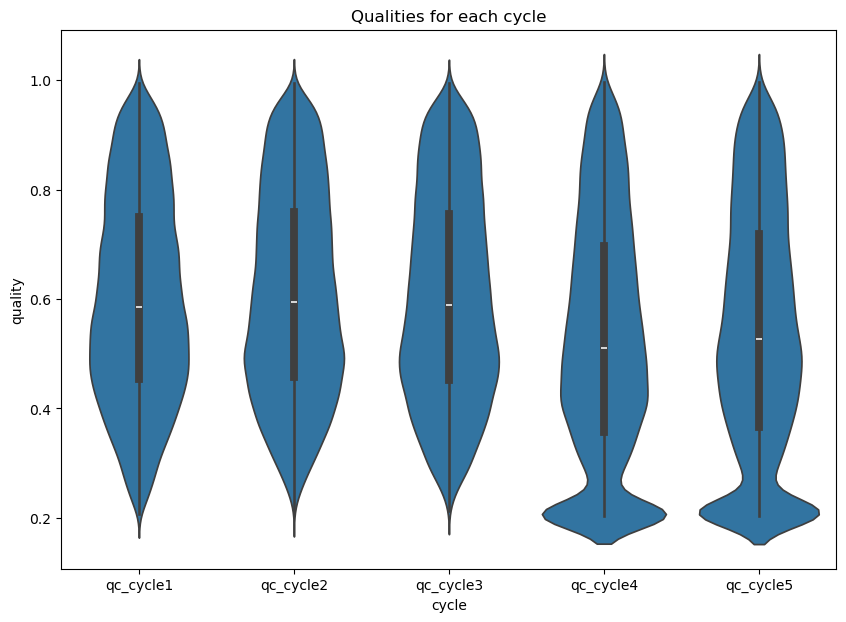

In [9]:
QC.quality_per_cycle(reads)

Another useful plot to generate is to see how quality score metrics reflect whether a read has a match on the codebook ("assigned") or not ("non assigned"). We plot the `quality_minimum` and `quality_mean` against the assignment/non assignment to understand which is the best strategy to filter our data. Ideally we should infer from this plot a good quality threshold for filtering our data. 

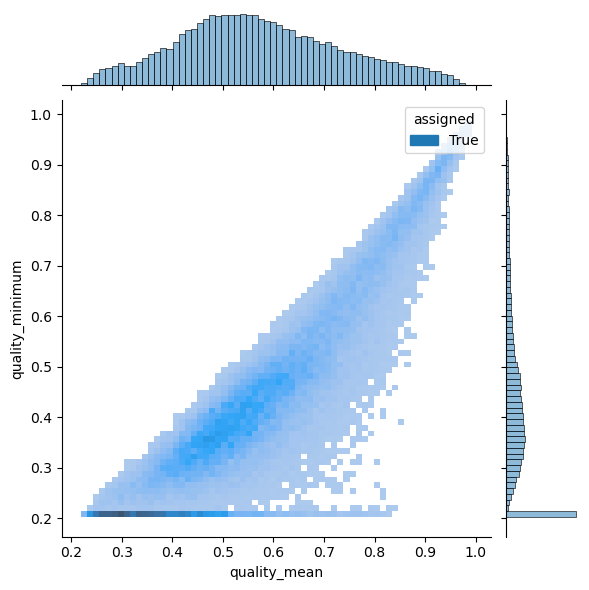

In [10]:
QC.compare_scores(reads,score1='quality_mean',score2='quality_minimum',hue='assigned',kind='hist',color='#3266a8')


The following command does the same, but only on a single score.

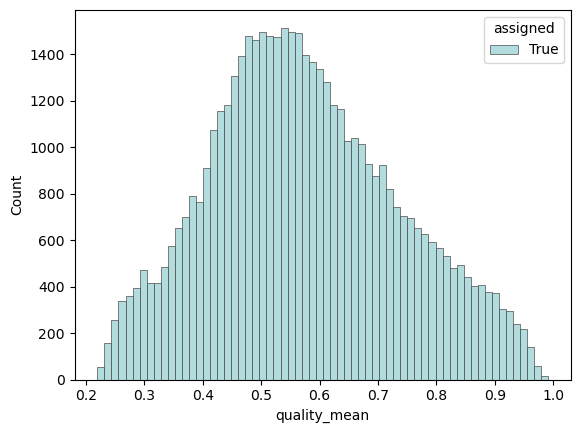

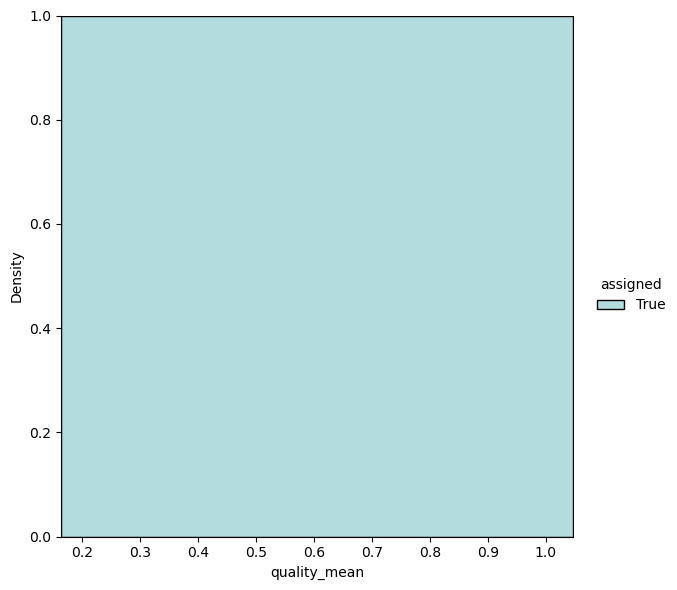

In [14]:
QC.plot_scores(reads, on='quality_mean', hue='assigned', log_scale=False)


## Filtering the data

There are different strategies to filter the data, depending on what the above plots show. You can refer to the manual for more specific example.

A general common sense criterion is to filter out all the reads whose `quality_minimum` is < 0.5
This discards all the reads that show poor quality in **at least one cycle**. This is quite a conservative criterion, but as a rule of thumb is a good one.


Other methods for filtering are also described in the relevant part of the manual.

In [15]:
reads_filt=QC.filter_reads(reads,min_quality_minimum=0.5)


The number of filtered reads for this section is:

In [16]:
len(reads_filt)

14170

# Plot expression data (currently deprecated in favor of TissUUmaps)

After quality-filtering, a sensible thing to do is to plot the gene expression decoded from your tissue. 

Parameters `xcolumn` and `ycolumn` define the XY positions of your spots in the `reads_filt` dataframe. 

`key` points to the column containing the gene identity of your spots in the `reads_filt` dataframe.

`genes` allows to plot a single gene per plot (=`individual`), or to plots all genes in a single plot (=`all`)

`size`= sets the dot size

`background`= sets the background color	

`title_color`= sets the color of the title for each plot.

`colorcode`= sets the color of the expression dots

`figuresize`=(10,10) sets the size of the plot

`save`= defaults to `None`. If `True` saves the plot in the speficied `format`

`format`= saves the plot to a specific format (ie `pdf`)


In [ ]:
QC.plot_expression(reads,key='target',colorcode=['red'],xcolumn='xc',ycolumn='yc',genes='individual',size=8,background='black',title_color='white',figuresize=(10,10),save=None,format='pdf')


## Other useful functions

`quality_per_gene`: this function plots the quality of the reads assigned to each gene. Since every gene has an associated sequence of colors across cycles, we might have a big quality bias between different genes arising just because of the colour sequence (ie. if a channel has always a bad signal/noise, genes with many cycles in that channels will always have lower quality).

In [20]:
QC.quality_per_gene(reads,on='quality_mean',gene_name='target')

TypeError: agg function failed [how->mean,dtype->object]

`plot_frequencies`: allows us to plot the relative abundance of the decoded dots for each gene. This is useful to identify potential decoding artefacts. For example, a gene that looks 1000 times more abundant than the second more represented gene, should raise an eyebrow.

In [21]:
QC.plot_frequencies(reads,on='target')

KeyError: 'fov'